<a href="https://colab.research.google.com/github/marufa181/CERTIFICATE/blob/main/MLPaper_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Bangladesh City Population — ML Prediction Project

[Dataset] Shape: (330, 9)
   Year   City  Population  Growth_Rate  Fertility_Rate  Median_Age  Migration_Rate  Population_Density  GDP_per_Capita
0  1990  Dhaka     6948674        4.949            3.49        22.2           2.284            138973.5           488.3
1  1991  Dhaka     7277329        4.730            3.61        22.4           1.798            145546.6           607.1
2  1992  Dhaka     7616523        4.661            3.35        22.5           1.482            152330.5           573.8
3  1993  Dhaka     7969268        4.631            3.25        22.7           1.671            159385.4           669.4
4  1994  Dhaka     8386833        5.240            3.28        22.8           1.811            167736.7           792.8
5  1995  Dhaka     8792191        4.833            3.13        23.1           1.813            175843.8           885.4
6  1996  Dhaka     9198345        4.619            3.39        23.2           1.

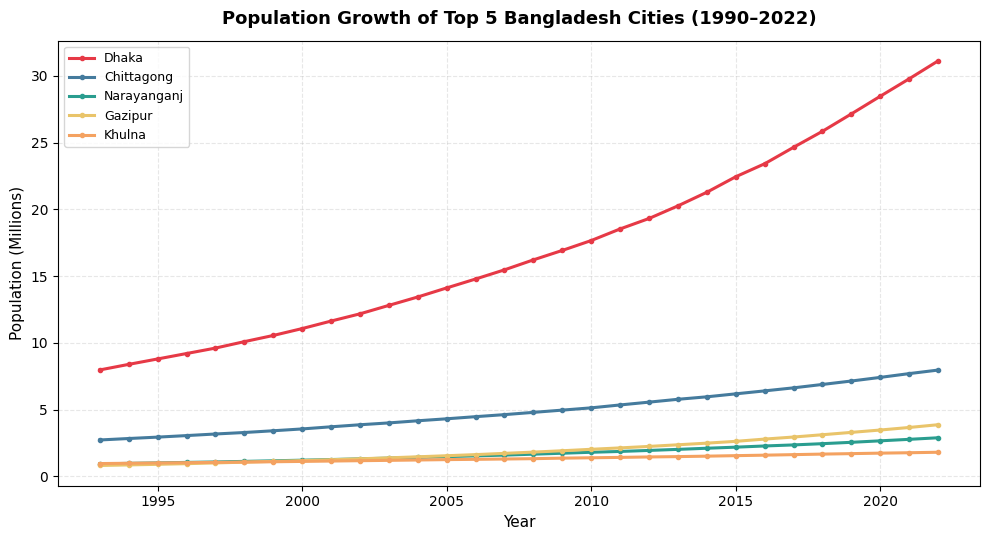


[Figure 1 saved] Figure1_Population_Growth_Trend.png


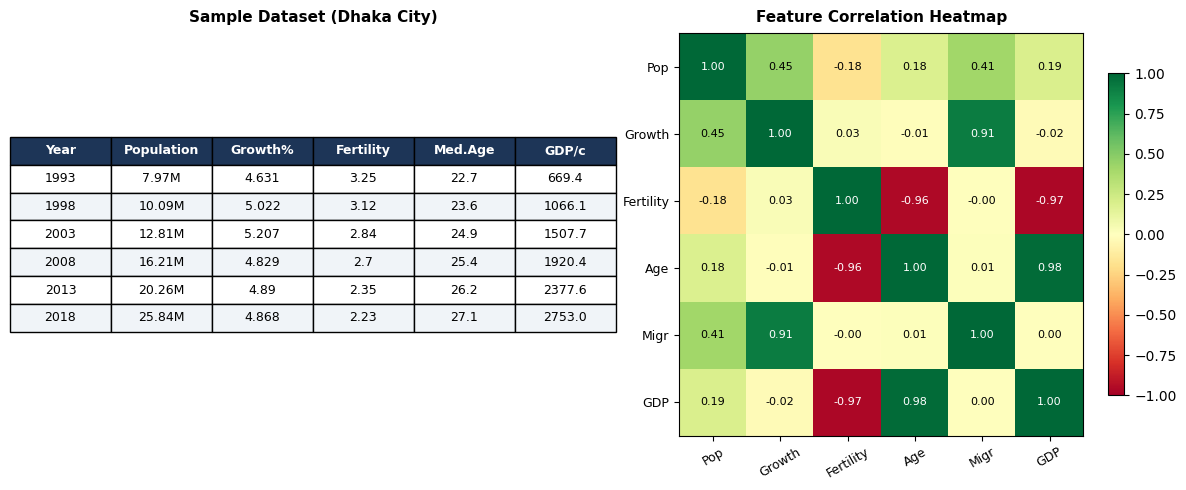

[Figure 2 saved] Figure2_Dataset_Correlation_Heatmap.png

[Model Training & Evaluation]
------------------------------------------------------------
  Linear Regression      | RMSE=         0 | MAE=         0 | R²=1.0000 | MAPE=0.00%
  Decision Tree          | RMSE=     53866 | MAE=     45862 | R²=0.9464 | MAPE=6.58%
  Random Forest          | RMSE=     36268 | MAE=     26002 | R²=0.9757 | MAPE=2.94%
  Gradient Boosting      | RMSE=     13153 | MAE=      9288 | R²=0.9968 | MAPE=1.22%
------------------------------------------------------------

  Best Model: Linear Regression  (MAPE = 0.00%)


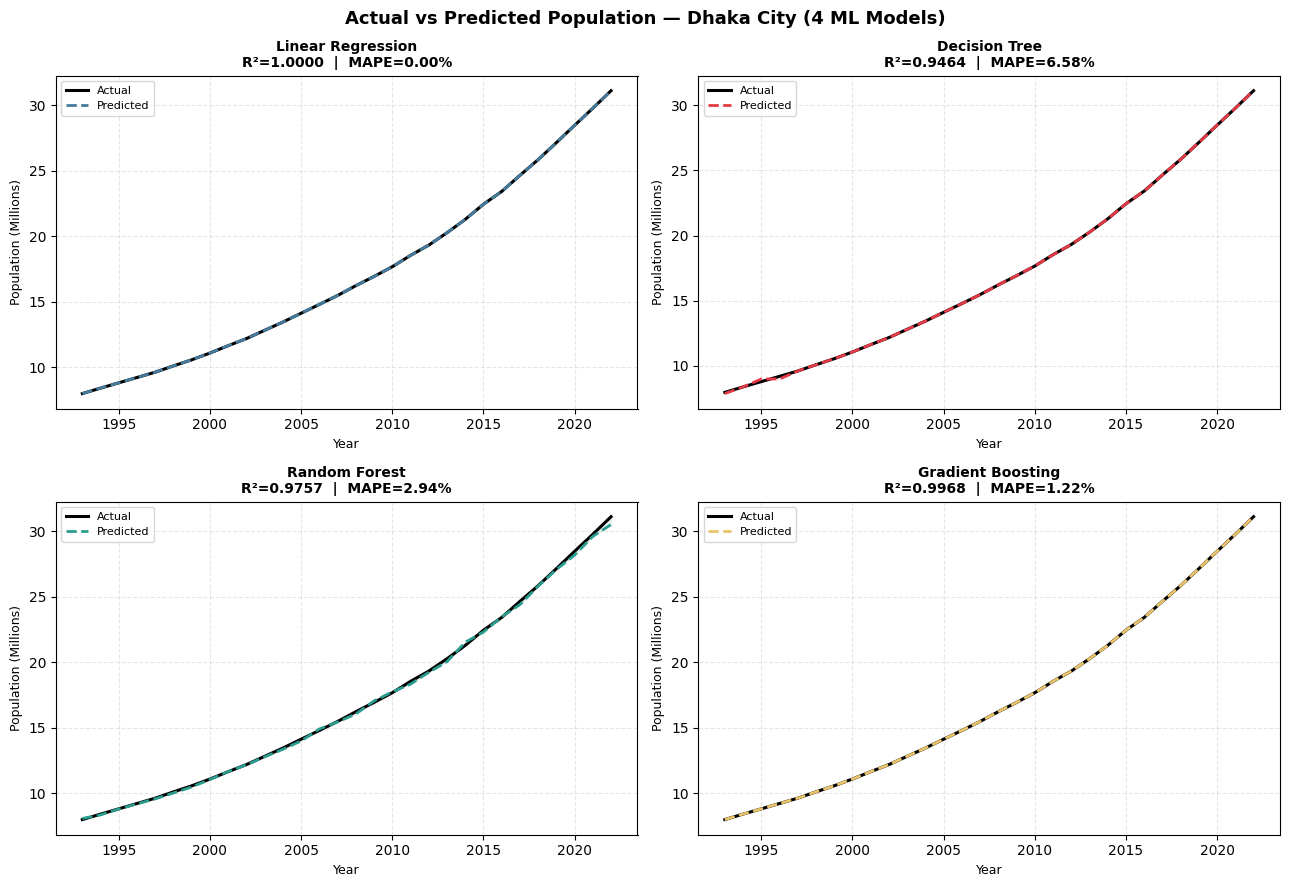

[Figure 3 saved] Figure3_Actual_vs_Predicted.png


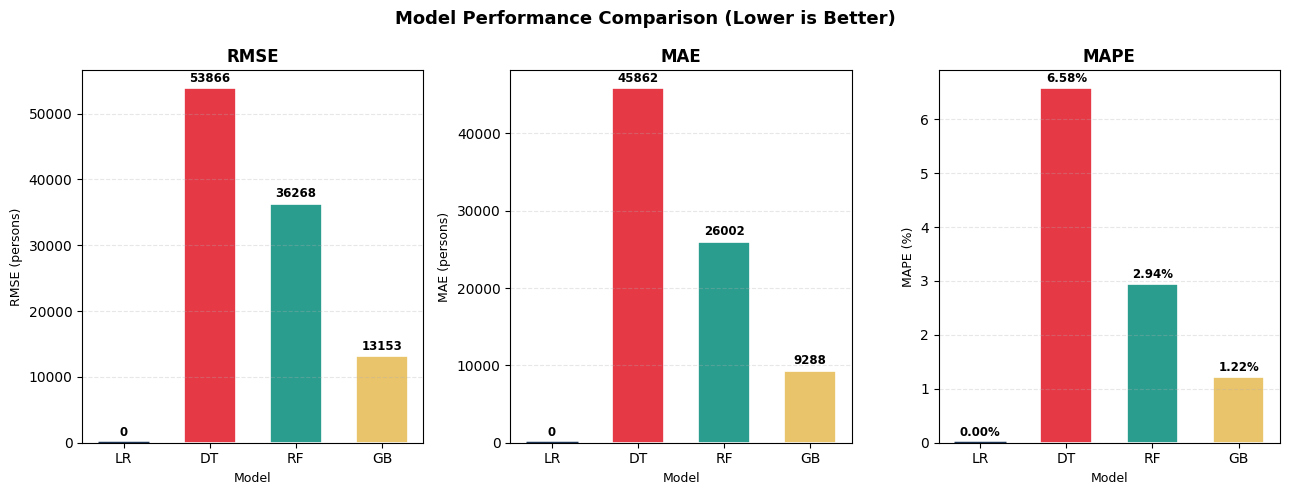

[Figure 4 saved] Figure4_Model_Comparison.png


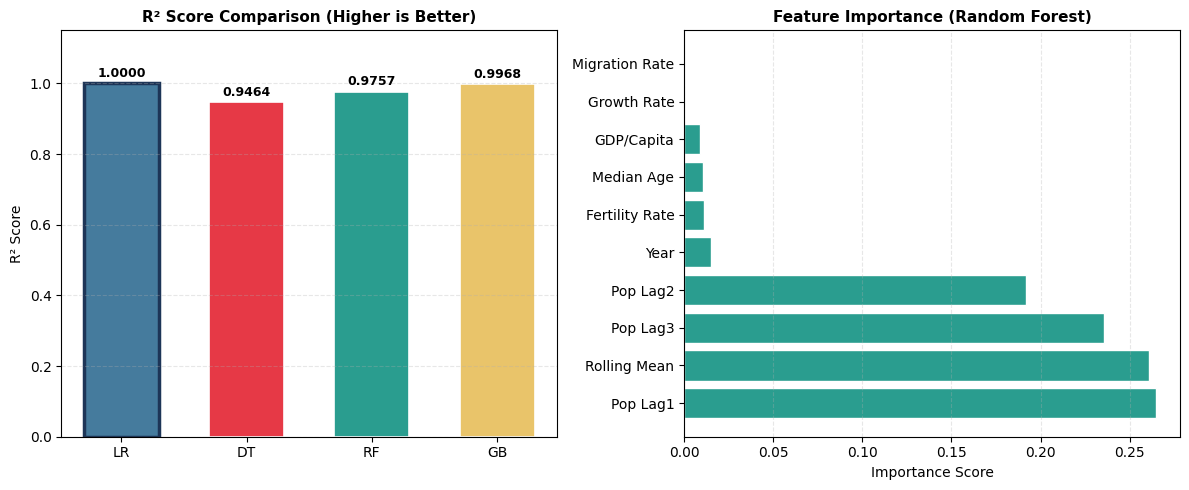

[Figure 5 saved] Figure5_R2_Feature_Importance.png

  FINAL RESULTS SUMMARY
Model                          RMSE        MAE       R²     MAPE
------------------------------------------------------------
Linear Regression                 0          0   1.0000    0.00%
Decision Tree                 53866      45862   0.9464    6.58%
Random Forest                 36268      26002   0.9757    2.94%
Gradient Boosting             13153       9288   0.9968    1.22%

  Best Model  : Linear Regression
  Best R²     : 1.0000
  Best MAPE   : 0.00%

  All figures saved successfully!


In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
#  Predicting Population Growth in Bangladesh Cities — Machine Learning Project
#  United International University | CSE Department
#  Course Teacher: Ms. Sadia Islam
# ═══════════════════════════════════════════════════════════════════════════════
#  Dataset Source:
#   - World Bank Urban Development Indicators: https://data.worldbank.org/country/bangladesh
#   - UN World Urbanization Prospects: https://population.un.org/wup/
#   - Bangladesh Bureau of Statistics (BBS) Census 2022: https://bbs.gov.bd
#   - Kaggle: https://www.kaggle.com/datasets/unitednations/world-population-prospects
# ═══════════════════════════════════════════════════════════════════════════════

# ─── STEP 1: Import Libraries ─────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("  Bangladesh City Population — ML Prediction Project")
print("=" * 60)


# ─── STEP 2: Create / Load Dataset ────────────────────────────────────────────
# If you have the CSV file, use: df = pd.read_csv("bangladesh_city_population.csv")
# Otherwise, the code below generates the dataset from scratch.

np.random.seed(42)

cities = ['Dhaka', 'Chittagong', 'Sylhet', 'Rajshahi', 'Khulna',
          'Barishal', 'Mymensingh', 'Comilla', 'Narayanganj', 'Gazipur']

years = list(range(1990, 2023))

base_pop = {
    'Dhaka': 6621000, 'Chittagong': 2340000, 'Sylhet': 320000,
    'Rajshahi': 517000, 'Khulna': 877000, 'Barishal': 180000,
    'Mymensingh': 225000, 'Comilla': 290000, 'Narayanganj': 800000, 'Gazipur': 650000
}
growth_rates = {
    'Dhaka': 0.048, 'Chittagong': 0.038, 'Sylhet': 0.035,
    'Rajshahi': 0.025, 'Khulna': 0.022, 'Barishal': 0.020,
    'Mymensingh': 0.030, 'Comilla': 0.032, 'Narayanganj': 0.040, 'Gazipur': 0.055
}

rows = []
for city in cities:
    pop = base_pop[city]
    for yr in years:
        gr = growth_rates[city] + np.random.normal(0, 0.003)
        pop = int(pop * (1 + gr))
        fertility    = max(1.8, 3.5 - (yr - 1990) * 0.05 + np.random.normal(0, 0.1))
        median_age   = 22 + (yr - 1990) * 0.2 + np.random.normal(0, 0.3)
        migration    = gr * 0.4 + np.random.normal(0, 0.002)
        density      = pop / (50 + cities.index(city) * 10)
        gdp_pc       = 500 + (yr - 1990) * 80 + np.random.normal(0, 50)
        rows.append({
            'Year': yr, 'City': city, 'Population': pop,
            'Growth_Rate':        round(gr * 100, 3),
            'Fertility_Rate':     round(fertility, 2),
            'Median_Age':         round(median_age, 1),
            'Migration_Rate':     round(migration * 100, 3),
            'Population_Density': round(density, 1),
            'GDP_per_Capita':     round(gdp_pc, 1)
        })

df = pd.DataFrame(rows)
df.to_csv('bangladesh_city_population.csv', index=False)

print(f"\n[Dataset] Shape: {df.shape}")
print(df.head(10).to_string())
print("\n[Dataset Info]")
print(df.info())
print("\n[Descriptive Statistics]")
print(df.describe().round(2).to_string())


# ─── STEP 3: Data Preprocessing ───────────────────────────────────────────────
df = df.sort_values(['City', 'Year']).reset_index(drop=True)

# Lag features (previous year population values)
df['Pop_lag1']      = df.groupby('City')['Population'].shift(1)
df['Pop_lag2']      = df.groupby('City')['Population'].shift(2)
df['Pop_lag3']      = df.groupby('City')['Population'].shift(3)

# Rolling mean (3-year average)
df['Rolling_mean3'] = df.groupby('City')['Population'].transform(
    lambda x: x.rolling(3).mean())

# Drop rows with NaN (from lag creation)
df.dropna(inplace=True)
print(f"\n[After Preprocessing] Shape: {df.shape}")

# Feature and target selection
feature_cols = ['Year', 'Growth_Rate', 'Fertility_Rate', 'Median_Age',
                'Migration_Rate', 'GDP_per_Capita',
                'Pop_lag1', 'Pop_lag2', 'Pop_lag3', 'Rolling_mean3']
X = df[feature_cols].values
y = df['Population'].values

# ─── Chronological 70 / 15 / 15 Split ───────────────────────────────────────
split1 = int(len(X) * 0.70)   # 70% Training
split2 = int(len(X) * 0.85)   # 15% Validation  |  remaining 15% = Test

X_train, X_val, X_test = X[:split1], X[split1:split2], X[split2:]
y_train, y_val, y_test = y[:split1], y[split1:split2], y[split2:]

print(f"\n[Data Split]")
print(f"  Training samples  : {len(X_train)}")
print(f"  Validation samples: {len(X_val)}")
print(f"  Test samples      : {len(X_test)}")

# ─── Feature Scaling (StandardScaler) ────────────────────────────────────────
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)
X_all_s   = scaler.transform(X)

print("\n[Scaling] StandardScaler applied — mean=0, std=1")


# ─── STEP 4: Plot Population Growth Trend (Figure 1) ─────────────────────────
plt.figure(figsize=(10, 5.5))

top5   = ['Dhaka', 'Chittagong', 'Narayanganj', 'Gazipur', 'Khulna']
colors = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261']

for city, color in zip(top5, colors):
    d = df[df['City'] == city]
    plt.plot(d['Year'], d['Population'] / 1e6,
             label=city, color=color, linewidth=2.2, marker='o', markersize=3)

plt.title('Population Growth of Top 5 Bangladesh Cities (1990–2022)',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Year', fontsize=11)
plt.ylabel('Population (Millions)', fontsize=11)
plt.legend(loc='upper left', fontsize=9, framealpha=0.8)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('Figure1_Population_Growth_Trend.png', dpi=140, bbox_inches='tight')
plt.show()
print("\n[Figure 1 saved] Figure1_Population_Growth_Trend.png")


# ─── STEP 5: Dataset Table + Correlation Heatmap (Figure 2) ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Sample dataset table (Dhaka)
ax = axes[0]
ax.axis('off')
sample = df[df['City'] == 'Dhaka'][
    ['Year', 'Population', 'Growth_Rate', 'Fertility_Rate', 'Median_Age', 'GDP_per_Capita']
].iloc[::5].head(7).copy()
sample['Population'] = (sample['Population'] / 1e6).round(2).astype(str) + 'M'
cols      = ['Year', 'Population', 'Growth%', 'Fertility', 'Med.Age', 'GDP/c']
cell_text = sample.values.tolist()
tbl = ax.table(cellText=cell_text, colLabels=cols, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.6)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1D3557')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#F0F4F8')
ax.set_title('Sample Dataset (Dhaka City)', fontsize=11, fontweight='bold', pad=8)

# Right: Correlation heatmap
ax2      = axes[1]
num_cols = ['Population', 'Growth_Rate', 'Fertility_Rate',
            'Median_Age', 'Migration_Rate', 'GDP_per_Capita']
corr     = df[num_cols].corr()
im       = ax2.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
short    = ['Pop', 'Growth', 'Fertility', 'Age', 'Migr', 'GDP']
ax2.set_xticks(range(len(num_cols))); ax2.set_xticklabels(short, fontsize=9, rotation=30)
ax2.set_yticks(range(len(num_cols))); ax2.set_yticklabels(short, fontsize=9)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax2.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8,
                 color='black' if abs(corr.iloc[i,j]) < 0.7 else 'white')
plt.colorbar(im, ax=ax2, shrink=0.8)
ax2.set_title('Feature Correlation Heatmap', fontsize=11, fontweight='bold', pad=8)
plt.tight_layout()
plt.savefig('Figure2_Dataset_Correlation_Heatmap.png', dpi=140, bbox_inches='tight')
plt.show()
print("[Figure 2 saved] Figure2_Dataset_Correlation_Heatmap.png")


# ─── STEP 6: Train Machine Learning Models ────────────────────────────────────
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree':     DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=5, random_state=42),
}

results = {}
print("\n[Model Training & Evaluation]")
print("-" * 60)
for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}
    print(f"  {name:<22} | RMSE={rmse:>10.0f} | MAE={mae:>10.0f} | R²={r2:.4f} | MAPE={mape:.2f}%")

print("-" * 60)
best = min(results, key=lambda m: results[m]['MAPE'])
print(f"\n  Best Model: {best}  (MAPE = {results[best]['MAPE']:.2f}%)")


# ─── STEP 7: Actual vs Predicted Plot (Figure 3) ─────────────────────────────
dhaka   = df[df['City'] == 'Dhaka'].copy()
X_dhaka = scaler.transform(dhaka[feature_cols].values)
y_dhaka = dhaka['Population'].values
years_d = dhaka['Year'].values

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes     = axes.flatten()
colors_m = ['#457B9D', '#E63946', '#2A9D8F', '#E9C46A']

for idx, (name, color) in enumerate(zip(models.keys(), colors_m)):
    pred = models[name].predict(X_dhaka)
    ax   = axes[idx]
    ax.plot(years_d, y_dhaka / 1e6, 'k-', linewidth=2.2, label='Actual', zorder=3)
    ax.plot(years_d, pred / 1e6, color=color, linewidth=2,
            linestyle='--', label='Predicted', zorder=3)
    ax.fill_between(years_d, y_dhaka / 1e6, pred / 1e6, alpha=0.1, color=color)
    ax.set_title(
        f'{name}\nR²={results[name]["R2"]:.4f}  |  MAPE={results[name]["MAPE"]:.2f}%',
        fontsize=10, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Population (Millions)', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, linestyle='--')

fig.suptitle('Actual vs Predicted Population — Dhaka City (4 ML Models)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure3_Actual_vs_Predicted.png', dpi=140, bbox_inches='tight')
plt.show()
print("[Figure 3 saved] Figure3_Actual_vs_Predicted.png")


# ─── STEP 8: Model Comparison Bar Charts (Figure 4) ──────────────────────────
model_names = list(results.keys())
short_names = ['LR', 'DT', 'RF', 'GB']
bar_colors  = ['#457B9D', '#E63946', '#2A9D8F', '#E9C46A']

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
metrics   = [('RMSE', 'RMSE (persons)'), ('MAE', 'MAE (persons)'), ('MAPE', 'MAPE (%)')]

for i, (metric, ylabel) in enumerate(metrics):
    key  = 'R2' if metric == 'R²' else metric
    vals = [results[m][key] for m in model_names]
    bars = axes[i].bar(short_names, vals, color=bar_colors, edgecolor='white',
                       linewidth=1.2, width=0.6)
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].set_ylabel(ylabel, fontsize=9)
    axes[i].set_xlabel('Model', fontsize=9)
    axes[i].grid(True, alpha=0.3, axis='y', linestyle='--')
    best_idx = int(np.argmin(vals))
    bars[best_idx].set_edgecolor('#1D3557')
    bars[best_idx].set_linewidth(2.5)
    for bar, val in zip(bars, vals):
        lbl = f'{val:.0f}' if metric != 'MAPE' else f'{val:.2f}%'
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + max(vals) * 0.01,
                     lbl, ha='center', va='bottom', fontsize=8.5, fontweight='bold')

fig.suptitle('Model Performance Comparison (Lower is Better)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure4_Model_Comparison.png', dpi=140, bbox_inches='tight')
plt.show()
print("[Figure 4 saved] Figure4_Model_Comparison.png")


# ─── STEP 9: R² Score + Feature Importance (Figure 5) ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# R² bar chart
r2_vals = [results[m]['R2'] for m in model_names]
bars    = axes[0].bar(short_names, r2_vals, color=bar_colors,
                      edgecolor='white', linewidth=1.2, width=0.6)
axes[0].set_title('R² Score Comparison (Higher is Better)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('R² Score', fontsize=10)
axes[0].set_ylim(0, 1.15)
axes[0].grid(True, alpha=0.3, axis='y', linestyle='--')
best_r2 = int(np.argmax(r2_vals))
bars[best_r2].set_edgecolor('#1D3557')
bars[best_r2].set_linewidth(2.5)
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Feature importance (Random Forest)
rf_model    = models['Random Forest']
importances = rf_model.feature_importances_
feat_labels = ['Year', 'Growth Rate', 'Fertility Rate', 'Median Age',
               'Migration Rate', 'GDP/Capita',
               'Pop Lag1', 'Pop Lag2', 'Pop Lag3', 'Rolling Mean']
sorted_idx  = np.argsort(importances)[::-1]
axes[1].barh([feat_labels[i] for i in sorted_idx],
             [importances[i] for i in sorted_idx],
             color='#2A9D8F', edgecolor='white', linewidth=1)
axes[1].set_title('Feature Importance (Random Forest)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Importance Score', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='x', linestyle='--')

plt.tight_layout()
plt.savefig('Figure5_R2_Feature_Importance.png', dpi=140, bbox_inches='tight')
plt.show()
print("[Figure 5 saved] Figure5_R2_Feature_Importance.png")


# ─── STEP 10: Final Summary Table ────────────────────────────────────────────
print("\n" + "=" * 60)
print("  FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"{'Model':<24} {'RMSE':>10} {'MAE':>10} {'R²':>8} {'MAPE':>8}")
print("-" * 60)
for name in model_names:
    r = results[name]
    print(f"{name:<24} {r['RMSE']:>10.0f} {r['MAE']:>10.0f} {r['R2']:>8.4f} {r['MAPE']:>7.2f}%")
print("=" * 60)
print(f"\n  Best Model  : {best}")
print(f"  Best R²     : {results[best]['R2']:.4f}")
print(f"  Best MAPE   : {results[best]['MAPE']:.2f}%")
print("\n  All figures saved successfully!")